In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## UKBB ##

In [54]:
# Keep only the features which are present in validation set

training_df=pd.read_csv('training_df.csv',index_col=0)
test_df=pd.read_csv('test_df.csv',index_col=0)
training_df.head()

cols_to_keep=[ 'RBC','Hbconc', 'MCV', 'RDW', 'platelet', 'plateletcrit', 'lymphocyte',
       'monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'age','giant_plt','CH']

training_df_HMDR=training_df[cols_to_keep]
test_df_HMDR=test_df[cols_to_keep]

X_train_HMDR=training_df_HMDR.drop(columns=['CH'])
y_train_HMDR=training_df_HMDR[['CH']]
X_test_HMDR=test_df_HMDR.drop(columns=['CH'])
y_test_HMDR=test_df_HMDR[['CH']]

### Training cohort statistics ###

In [55]:
print(len(training_df))
print(training_df['age'].mean(),training_df['age'].std())
print((training_df['sex']==1).sum(),(training_df['sex']==0).sum())
print((training_df['MN']==0).sum(),(training_df['MN']==1).sum())

369296
57.01854903203211 8.082673217273426
169450 199846
368019 1277


In [62]:
training_df['CHRS'].value_counts()

CHRS
0.0     346288
8.0       7449
7.5       6698
8.5       2950
9.0       2074
9.5       1832
10.0       833
10.5       505
11.0       273
11.5       130
12.0       115
12.5        59
13.0        38
13.5        29
14.0        16
14.5         4
15.0         2
15.5         1
Name: count, dtype: int64

In [56]:
# Define conditions
anemia = ((training_df['sex'] == 0) & (training_df['Hbconc'] < 12)) | ((training_df['sex'] == 1) & (training_df['Hbconc'] < 13))
neutropenia = training_df['neutrophil'] < 1.8
thrombocytopenia = training_df['platelet'] < 150

# CCUS
any_condition = anemia | neutropenia | thrombocytopenia

# CCUS
CCUS = training_df[any_condition].shape[0]

# CHIP
CHIP = training_df[~any_condition].shape[0]

# Print results
print("Number with CCUS:", CCUS)
print("Number with CHIP:", CHIP)

Number with CCUS: 26447
Number with CHIP: 342849


In [57]:
# 1. Actual number of high-risk individuals in the training set
hirisk_true = (training_df['CHRS'] >= 12.5).sum()
intermediate_true = ((training_df['CHRS'] >= 10)&(training_df['CHRS'] < 12.5)).sum()
lowrisk_true = ((training_df['CHRS'] > 0)&(training_df['CHRS'] < 10)).sum()
norisk_true = (training_df['CHRS'] == 0).sum()

hirisk_true,intermediate_true,lowrisk_true,norisk_true

(149, 1856, 21003, 346288)

In [58]:
training_df['CH'].value_counts()

CH
0.0    364128
1.0      4877
2.0       291
Name: count, dtype: int64

In [59]:
(training_df['CH_score']>4).sum()

5168

### Test cohort statistics ###

In [38]:
print(len(test_df))
print(test_df['age'].mean(),test_df['age'].std())
print((test_df['sex']==1).sum(),(test_df['sex']==0).sum())
print((test_df['MN']==0).sum(),(test_df['MN']==1).sum())

92324
57.060234428028835 8.088780396355594
42201 50123
91960 364


In [40]:
# Define conditions
anemia = ((test_df['sex'] == 0) & (test_df['Hbconc'] < 12)) | ((test_df['sex'] == 1) & (test_df['Hbconc'] < 13))
neutropenia = test_df['neutrophil'] < 1.8
thrombocytopenia = test_df['platelet'] < 150

# CCUS
any_condition = anemia | neutropenia | thrombocytopenia

# CCUS
CCUS = test_df[any_condition].shape[0]

# CHIP
CHIP = test_df[~any_condition].shape[0]

# Print results
print("Number with CCUS:", CCUS)
print("Number with CHIP:", CHIP)

Number with CCUS: 6617
Number with CHIP: 85707


In [60]:
# 1. Actual number of high-risk individuals in the training set
hirisk_true = (test_df['CHRS'] >= 12.5).sum()
intermediate_true = ((test_df['CHRS'] >= 10)&(test_df['CHRS'] < 12.5)).sum()
lowrisk_true = ((test_df['CHRS'] > 0)&(test_df['CHRS'] < 10)).sum()
norisk_true = (test_df['CHRS'] == 0).sum()

hirisk_true,intermediate_true,lowrisk_true,norisk_true

(43, 430, 5336, 86515)

In [61]:
test_df['CH'].value_counts()

CH
0.0    91032
1.0     1219
2.0       73
Name: count, dtype: int64

### load model ###

In [4]:
# Load the saved model
import pickle
with open("3class_giantplt_HMDR.pkl", "rb") as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
loaded_features = loaded_package['features']

In [5]:
loaded_features

Index(['RBC', 'Hbconc', 'MCV', 'MCHb', 'RDW', 'platelet', 'plateletcrit',
       'lymphocyte', 'monocyte', 'neutrophil', 'eosinophil', 'reticulocyte',
       'MRV', 'MspCV', 'immret', 'age', 'giant_plt'],
      dtype='object')

### AUC and thresholds ###

/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


class, theshold, gmeans: 0 0.39157247447765736
class, theshold, gmeans: 1 0.35633099340083335
class, theshold, gmeans: 2 0.2716519816427712


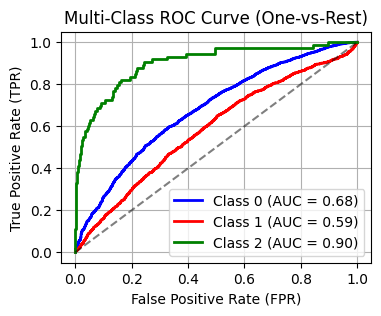

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Binarize the labels for multi-class classification
n_classes = len(np.unique(y_test_HMDR))  # Number of classes
y_test_bin = label_binarize(y_test_HMDR, classes=np.unique(y_test_HMDR))  # Convert to one-hot encoding

loaded_model.fit(X_train_HMDR,y_train_HMDR)
y_pred_proba = loaded_model.predict_proba(X_test_HMDR)


# Plot ROC curve for each class
plt.figure(figsize=(4, 3))

colors = ['blue', 'red', 'green', 'brown']  # Adjust for more classes

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])  # Compute ROC for class i
    roc_auc = auc(fpr, tpr)  # Compute AUC
    ix=np.argmax(tpr-fpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')
    print("class, theshold, gmeans:",i, thresholds[ix])

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and legend
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()

### Confusion Matrix and Accuracy ###


Accuracy Score: 0.5390
Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.54      0.70     91032
         1.0       0.02      0.51      0.04      1219
         2.0       0.00      0.70      0.01        73

    accuracy                           0.54     92324
   macro avg       0.34      0.58      0.25     92324
weighted avg       0.98      0.54      0.69     92324



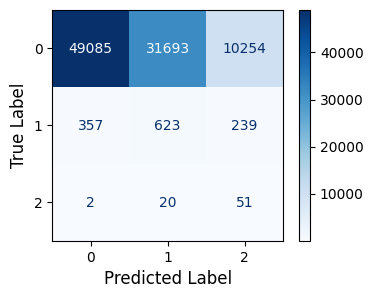

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Optimal thresholds (as computed earlier)
# Order: class 0, class 1, ..., class 5
thresholds = np.array([0.39157247447765736,0.35633099340083335,0.2716519816427712])

# Get predicted probabilities from the best model
y_proba = loaded_model.predict_proba(X_test_HMDR)  # shape: (n_samples, 6)

# Initialize an empty list for final predictions
y_pred_custom = []

# Iterate over each sample's probability vector
for prob_vector in y_proba:
    # Identify classes where probability exceeds its threshold
    passing_classes = np.where(prob_vector >= thresholds)[0]
    
    if passing_classes.size > 0:
        # If one or more classes pass, choose the one with highest probability among them
        chosen_class = passing_classes[np.argmax(prob_vector[passing_classes])]
    else:
        # Otherwise, default to the class with the maximum probability
        chosen_class = np.argmax(prob_vector)
    
    y_pred_custom.append(chosen_class)

# Convert list to numpy array
y_pred_custom = np.array(y_pred_custom)

# Evaluate the predictions
accuracy = accuracy_score(y_test_HMDR, y_pred_custom)
print(f"\nAccuracy Score: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test_HMDR, y_pred_custom))

# Compute confusion matrix
cm = confusion_matrix(y_test_HMDR, y_pred_custom)

# Plot confusion matrix with a custom colormap
cmap = sns.color_palette("Blues", as_cmap=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 10})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

### Prediction class analysis ###

In [12]:
# Check CHRS statistics of predicted labels 

# 1. Actual number of high-risk individuals in the test set
hirisk_true = (test_df['CHRS'] >= 12.5).sum()
intermediate_true = ((test_df['CHRS'] >= 10)&(test_df['CHRS'] < 12.5)).sum()
lowrisk_true = ((test_df['CHRS'] > 0)&(test_df['CHRS'] < 10)).sum()
norisk_true = (test_df['CHRS'] == 0).sum()
                      
#  Indices where the model predicted "CH positive with MN" (label 2)
mask_2 = (y_pred_custom == 2)
n_rows_2 = np.where(mask_2)[0]

#  Indices where the model predicted "CH positive without MN" (label 1)
mask_1 = (y_pred_custom == 1)
n_rows_1 = np.where(mask_1)[0]

#  Indices where the model predicted "Everyone else" (label 0)
mask_0 = (y_pred_custom == 0)
n_rows_0 = np.where(mask_0)[0]

# 3. Subset of X_test corresponding to predicted positive
predicted_class2_df = test_df.iloc[n_rows_2]
predicted_class1_df = test_df.iloc[n_rows_1]
predicted_class0_df = test_df.iloc[n_rows_0]

# 4. Among predicted positives, how many are high risk
hirisk_pred2 = (predicted_class2_df['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((predicted_class2_df['CHRS'] >= 10)&(predicted_class2_df['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((predicted_class2_df['CHRS'] > 0)&(predicted_class2_df['CHRS'] < 10)).sum()
norisk_pred2 = (predicted_class2_df['CHRS'] == 0).sum()

intermediate_pred1 = ((predicted_class1_df['CHRS'] >= 10)&(predicted_class1_df['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((predicted_class1_df['CHRS'] > 0)&(predicted_class1_df['CHRS'] < 10)).sum()
norisk_pred1 = (predicted_class1_df['CHRS'] == 0).sum()

intermediate_pred0 = ((predicted_class0_df['CHRS'] >= 10)&(predicted_class0_df['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((predicted_class0_df['CHRS'] > 0)&(predicted_class0_df['CHRS'] < 10)).sum()
norisk_pred0 = (predicted_class0_df['CHRS'] == 0).sum()

# 5. Print the results
print("Actual high-risk count:", hirisk_true)
print("Actual intermediate-risk count:", intermediate_true)
print("Actual low-risk count:", lowrisk_true)
print("Actual no-risk count:", norisk_true)

print("Actual high-risk count among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk count among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk count among predicted positives with MN:", lowrisk_pred2)
print("Actual norisk-risk count among predicted positives with MN:", norisk_pred2)

print("Actual intermediate-risk count among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk count among predicted positives without MN:", lowrisk_pred1)
print("Actual norisk-risk count among predicted positives without MN:", norisk_pred1)

print("Actual intermediate-risk count among predicted everyone else:", intermediate_pred0)
print("Actual low-risk count among everyone else:", lowrisk_pred0)
print("Actual norisk-risk count among everyone else:", norisk_pred0)


print("Percentage of actual high-risk correctly predicted:",round(hirisk_pred2 * 100 / hirisk_true, 2), "%")
print("Percentage of actual intermediate-risk predicted in positives classes 1 or 2:",round((intermediate_pred2+intermediate_pred1) * 100 / intermediate_true, 2), "%")
print("Percentage of actual intermediate-risk predicted in negative class:",round(intermediate_pred0 * 100 / intermediate_true, 2), "%")

Actual high-risk count: 43
Actual intermediate-risk count: 430
Actual low-risk count: 5336
Actual no-risk count: 86515
Actual high-risk count among predicted positives with MN: 43
Actual intermediate-risk count among predicted positives with MN: 235
Actual low-risk count among predicted positives with MN: 616
Actual norisk-risk count among predicted positives with MN: 9650
Actual intermediate-risk count among predicted positives without MN: 152
Actual low-risk count among predicted positives without MN: 2632
Actual norisk-risk count among predicted positives without MN: 29552
Actual intermediate-risk count among predicted everyone else: 43
Actual low-risk count among everyone else: 2088
Actual norisk-risk count among everyone else: 47313
Percentage of actual high-risk correctly predicted: 100.0 %
Percentage of actual intermediate-risk predicted in positives classes 1 or 2: 90.0 %
Percentage of actual intermediate-risk predicted in negative class: 10.0 %


In [101]:
# Among the 430 intermediate risk individuals, how many MN positives were classified in the positive classes?

intermediate_true_with_MN = ((test_df['CHRS'] >= 10)&(test_df['CHRS'] < 12.5)&(test_df['MN'] == 1)).sum()
print("Actual intermediate-risk count with MN:",intermediate_true_with_MN)

intermediate_pred2_with_MN = ((predicted_class2_df['CHRS'] >= 10)&(predicted_class2_df['CHRS'] < 12.5)&(predicted_class2_df['MN'] == 1)).sum()
intermediate_pred1_with_MN = ((predicted_class1_df['CHRS'] >= 10)&(predicted_class1_df['CHRS'] < 12.5)&(predicted_class1_df['MN'] == 1)).sum()

print("Actual intermediate-risk with MN count among predicted positives with MN:", intermediate_pred2_with_MN)
print("Actual intermediate-risk with MN count among predicted positives without MN:", intermediate_pred1_with_MN)
print("Percentage of actual intermediate-risk with MN predicted in positives classes 1 or 2:",
      round((intermediate_pred2_with_MN+intermediate_pred1_with_MN) * 100 / intermediate_true_with_MN, 2), "%")

Actual intermediate-risk count with MN: 34
Actual intermediate-risk with MN count among predicted positives with MN: 24
Actual intermediate-risk with MN count among predicted positives without MN: 10
Percentage of actual intermediate-risk with MN predicted in positives classes 1 or 2: 100.0 %


In [103]:
# Check statistics of CH positive patients with MN, in the predictions

# 1. Number of CH positive individuals with/ without MN
CHMN = ((test_df['CHRS'] > 0)&(test_df['MN']==1)).sum()
CHnoMN = ((test_df['CHRS'] > 0)&(test_df['MN']==0)).sum()
noCHMN = ((test_df['CHRS'] == 0)&(test_df['MN']==1)).sum()
noCHnoMN=((test_df['CHRS'] == 0)&(test_df['MN']==0)).sum()

print("Number of CH positive individuals with MN:",CHMN)
print("Number of CH positive individuals without MN:",CHnoMN)
print("Number of CH negative individuals with MN:",noCHMN)
print("Number of CH negative individuals without MN:",noCHnoMN)


# How many CH positive individuals with MN were classified in positive classes?
MN_pred2 = ((predicted_class2_df['CHRS'] > 0)&(predicted_class2_df['MN'] == 1)).sum()
MN_pred1 = ((predicted_class1_df['CHRS'] > 0)&(predicted_class1_df['MN'] == 1)).sum()

print("Number of CH positive individuals with MN predicted in the positive classes:",MN_pred2,MN_pred1)
print("Percentage of CH positive individuals with MN predicted in the positive classes:",
      round((MN_pred2+MN_pred1) * 100 / CHMN, 2), "%")

Number of CH positive individuals with MN: 111
Number of CH positive individuals without MN: 5698
Number of CH negative individuals with MN: 253
Number of CH negative individuals without MN: 86262
Number of CH positive individuals with MN predicted in the positive classes: 71 33
Percentage of CH positive individuals with MN predicted in the positive classes: 93.69 %


In [113]:
# Who are the 7 missed individuals??
predicted_class0_df[(predicted_class0_df['CHRS'] > 0)&(predicted_class0_df['MN'] == 1)][['gene1','gene2','VAF1','VAF2','age','sex','RDW','MCV','Hbconc','platelet','neutrophil','CH_score','CHRS']]

,gene1,gene2,VAF1,VAF2,age,sex,RDW,MCV,Hbconc,platelet,neutrophil,CH_score,CHRS
445794,DNMT3A,NaN,0.033,NaN,59.833333,1,13.10,92.70,15.20,180.0,5.20,3.5,7.5
352627,DNMT3A,NaN,0.207,NaN,60.666667,1,12.45,87.09,13.89,291.1,4.23,4.5,8.5
335996,DNMT3A,NaN,0.058,NaN,53.583333,0,13.70,90.90,13.50,380.0,4.30,3.5,7.5
205311,DNMT3A,NaN,0.138,NaN,58.250000,0,13.65,97.90,18.78,217.9,5.49,3.5,7.5
122541,DNMT3A,NaN,0.133,NaN,61.083333,1,13.15,89.29,14.72,208.2,3.27,3.5,7.5
235132,DNMT3A,NaN,0.163,NaN,58.833333,1,13.40,90.40,15.10,197.0,5.60,3.5,7.5
347252,DNMT3A,NaN,0.419,NaN,57.333333,0,12.96,93.73,12.88,322.4,2.25,4.5,8.5


## HMDR ##

In [33]:
# Test on validation set 

df_HMDR=pd.read_csv("/Users/riyanandi/Desktop/HMDR/HMDR_testdata_3class.csv",index_col=0)
df_HMDR.head()

,eosinophil,lymphocyte,monocyte,neutrophil,reticulocyte,MCV,RDW,RBC,Hbconc,platelet,MCHbconc,giant_plt,plateletcrit,score,sex,MN,age,CH,CHRS
0,0.00,0.49,0.40,4.05,0.034200,81.6,19.5,3.80,10.2,225.0,33.0,0,0.17775,3.5,0,0,92.000000,0.0,10.0
1,0.40,0.92,0.66,4.61,0.037980,88.8,16.9,4.22,12.2,132.0,32.7,0,0.11352,0.0,1,0,88.250000,0.0,0.0
2,0.05,0.72,0.56,5.46,0.075347,88.7,18.6,3.89,10.1,278.0,29.3,0,0.28912,0.0,0,0,48.916667,0.0,0.0
3,0.14,1.21,0.48,3.27,0.112294,82.2,14.0,4.81,13.1,167.0,33.2,0,0.15030,0.0,0,0,31.166667,0.0,0.0
4,0.08,0.65,0.17,1.19,0.053166,98.6,17.8,3.43,11.1,29.0,33.0,0,0.02813,0.0,0,0,42.833333,0.0,0.0


### HMDR cohort stats ###

In [34]:
print(len(df_HMDR))
print(df_HMDR['age'].mean(),df_HMDR['age'].std())
print((df_HMDR['sex']==1).sum(),(df_HMDR['sex']==0).sum())
print((df_HMDR['MN']==0).sum(),(df_HMDR['MN']==1).sum())

2466
63.55920519059205 16.042010614234016
1101 1365
2413 53


In [35]:
# Define conditions
anemia = ((df_HMDR['sex'] == 0) & (df_HMDR['Hbconc'] < 12)) | ((df_HMDR['sex'] == 1) & (df_HMDR['Hbconc'] < 13))
neutropenia = df_HMDR['neutrophil'] < 1.8
thrombocytopenia = df_HMDR['platelet'] < 150

# CCUS
any_condition = anemia | neutropenia | thrombocytopenia

# CCUS
CCUS = df_HMDR[any_condition].shape[0]

# CHIP
CHIP = df_HMDR[~any_condition].shape[0]

# Print results
print("Number with CCUS:", CCUS)
print("Number with CHIP:", CHIP)

Number with CCUS: 1639
Number with CHIP: 827


In [14]:
# On HMDR

X_HMDR=df_HMDR.drop(columns=['score','sex','MN','CH','CHRS'])
y_HMDR=df_HMDR[['CH']]
X_HMDR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2466 entries, 0 to 2465
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   eosinophil    2466 non-null   float64
 1   lymphocyte    2466 non-null   float64
 2   monocyte      2466 non-null   float64
 3   neutrophil    2466 non-null   float64
 4   reticulocyte  2466 non-null   float64
 5   MCV           2466 non-null   float64
 6   RDW           2466 non-null   float64
 7   RBC           2466 non-null   float64
 8   Hbconc        2466 non-null   float64
 9   platelet      2466 non-null   float64
 10  MCHbconc      2466 non-null   float64
 11  giant_plt     2466 non-null   int64  
 12  plateletcrit  2466 non-null   float64
 13  age           2466 non-null   float64
dtypes: float64(13), int64(1)
memory usage: 289.0 KB


In [15]:
features_kept=[ 'RBC','Hbconc', 'MCV', 'RDW', 'platelet', 'plateletcrit', 'lymphocyte',
       'monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'age','giant_plt']
X_reordered=X_HMDR[features_kept]
X_reordered.columns

Index(['RBC', 'Hbconc', 'MCV', 'RDW', 'platelet', 'plateletcrit', 'lymphocyte',
       'monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'age',
       'giant_plt'],
      dtype='object')

In [16]:
y_HMDR.value_counts()

CH 
0.0    1888
1.0     532
2.0      46
Name: count, dtype: int64

### AUC and threshold ###

class, theshold, gmeans: 0 0.22720794568821776
class, theshold, gmeans: 1 0.11356927111086054
class, theshold, gmeans: 2 0.5162691110933327


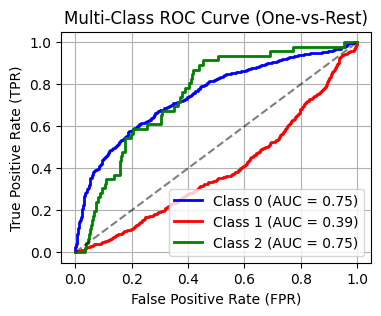

In [17]:
from sklearn.metrics import roc_curve, auc


# Binarize the labels for multi-class classification
n_classes = len(np.unique(y_HMDR))  # Number of classes
y_test_bin = label_binarize(y_HMDR, classes=np.unique(y_HMDR))  # Convert to one-hot encoding
y_pred_proba = loaded_model.predict_proba(X_reordered)  # Get predicted probabilities for each class

# Plot ROC curve for each class
plt.figure(figsize=(4, 3))

colors = ['blue', 'red', 'green']  # Adjust for more classes

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])  # Compute ROC for class i
    roc_auc = auc(fpr, tpr)  # Compute AUC
    ix=np.argmax(tpr-fpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')
    print("class, theshold, gmeans:",i, thresholds[ix])

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and legend
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid()

### Confusion Matrix and Accuracy ###


Accuracy Score: 0.3301
Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.34      0.50      1888
         1.0       0.20      0.25      0.22       532
         2.0       0.04      0.91      0.07        46

    accuracy                           0.33      2466
   macro avg       0.40      0.50      0.26      2466
weighted avg       0.77      0.33      0.43      2466



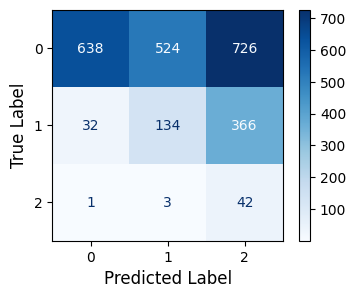

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Optimal thresholds (as computed earlier)
# Order: class 0, class 1, ..., class 5
thresholds = np.array([0.22720794568821776,0.11356927111086054,0.5162691110933327])

# Get predicted probabilities from the best model
y_proba = loaded_model.predict_proba(X_reordered)  # shape: (n_samples, 6)

# Initialize an empty list for final predictions
y_pred_custom = []

# Iterate over each sample's probability vector
for prob_vector in y_proba:
    # Identify classes where probability exceeds its threshold
    passing_classes = np.where(prob_vector >= thresholds)[0]
    
    if passing_classes.size > 0:
        # If one or more classes pass, choose the one with highest probability among them
        chosen_class = passing_classes[np.argmax(prob_vector[passing_classes])]
    else:
        # Otherwise, default to the class with the maximum probability
        chosen_class = np.argmax(prob_vector)
    
    y_pred_custom.append(chosen_class)

# Convert list to numpy array
y_pred_custom = np.array(y_pred_custom)

# Evaluate the predictions
accuracy = accuracy_score(y_HMDR, y_pred_custom)
print(f"\nAccuracy Score: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_HMDR, y_pred_custom))

# Compute confusion matrix
cm = confusion_matrix(y_HMDR, y_pred_custom)

# Plot confusion matrix with a custom colormap
cmap = sns.color_palette("Blues", as_cmap=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 10})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

### Prediction class analysis ###

In [21]:
# Check CHRS statistics of predicted labels 

# 1. Actual number of high-risk individuals in the test set
hirisk_true = (df_HMDR['CHRS'] >= 12.5).sum()
intermediate_true = ((df_HMDR['CHRS'] >= 10)&(df_HMDR['CHRS'] < 12.5)).sum()
lowrisk_true = ((df_HMDR['CHRS'] > 0)&(df_HMDR['CHRS'] < 10)).sum()
norisk_true = (df_HMDR['CHRS'] == 0).sum()
                      
#  Indices where the model predicted "CH positive with MN" (label 2)
mask_2 = (y_pred_custom == 2)
n_rows_2 = np.where(mask_2)[0]

#  Indices where the model predicted "CH positive without MN" (label 1)
mask_1 = (y_pred_custom == 1)
n_rows_1 = np.where(mask_1)[0]

#  Indices where the model predicted "Everyone else" (label 0)
mask_0 = (y_pred_custom == 0)
n_rows_0 = np.where(mask_0)[0]

# 3. Subset of X_test corresponding to predicted positive
predicted_class2_df = df_HMDR.iloc[n_rows_2]
predicted_class1_df = df_HMDR.iloc[n_rows_1]
predicted_class0_df = df_HMDR.iloc[n_rows_0]

# 4. Among predicted positives, how many are high risk
hirisk_pred2 = (predicted_class2_df['CHRS'] >= 12.5).sum()
intermediate_pred2 = ((predicted_class2_df['CHRS'] >= 10)&(predicted_class2_df['CHRS'] < 12.5)).sum()
lowrisk_pred2 = ((predicted_class2_df['CHRS'] > 0)&(predicted_class2_df['CHRS'] < 10)).sum()
norisk_pred2 = (predicted_class2_df['CHRS'] == 0).sum()

hirisk_pred1 = (predicted_class1_df['CHRS'] >= 12.5).sum()
intermediate_pred1 = ((predicted_class1_df['CHRS'] >= 10)&(predicted_class1_df['CHRS'] < 12.5)).sum()
lowrisk_pred1 = ((predicted_class1_df['CHRS'] > 0)&(predicted_class1_df['CHRS'] < 10)).sum()
norisk_pred1 = (predicted_class1_df['CHRS'] == 0).sum()

hirisk_pred0 = (predicted_class0_df['CHRS'] >= 12.5).sum()
intermediate_pred0 = ((predicted_class0_df['CHRS'] >= 10)&(predicted_class0_df['CHRS'] < 12.5)).sum()
lowrisk_pred0 = ((predicted_class0_df['CHRS'] > 0)&(predicted_class0_df['CHRS'] < 10)).sum()
norisk_pred0 = (predicted_class0_df['CHRS'] == 0).sum()

# 5. Print the results
print("Actual high-risk count:", hirisk_true)
print("Actual intermediate-risk count:", intermediate_true)
print("Actual low-risk count:", lowrisk_true)
print("Actual no-risk count:", norisk_true)

print("Actual high-risk count among predicted positives with MN:", hirisk_pred2)
print("Actual intermediate-risk count among predicted positives with MN:", intermediate_pred2)
print("Actual low-risk count among predicted positives with MN:", lowrisk_pred2)
print("Actual norisk-risk count among predicted positives with MN:", norisk_pred2)

print("Actual high-risk count among predicted positives without MN:", hirisk_pred1)
print("Actual intermediate-risk count among predicted positives without MN:", intermediate_pred1)
print("Actual low-risk count among predicted positives without MN:", lowrisk_pred1)
print("Actual norisk-risk count among predicted positives without MN:", norisk_pred1)

print("Actual high-risk count among everyone else:", hirisk_pred0)
print("Actual intermediate-risk count among predicted everyone else:", intermediate_pred0)
print("Actual low-risk count among everyone else:", lowrisk_pred0)
print("Actual norisk-risk count among everyone else:", norisk_pred0)


print("Percentage of actual high-risk correctly predicted:",round(hirisk_pred2 * 100 / hirisk_true, 2), "%")
print("Percentage of actual intermediate-risk predicted in positives classes 1 or 2:",round((intermediate_pred2+intermediate_pred1) * 100 / intermediate_true, 2), "%")
print("Percentage of actual intermediate-risk predicted in negative class:",round(intermediate_pred0 * 100 / intermediate_true, 2), "%")

Actual high-risk count: 251
Actual intermediate-risk count: 429
Actual low-risk count: 278
Actual no-risk count: 1508
Actual high-risk count among predicted positives with MN: 226
Actual intermediate-risk count among predicted positives with MN: 302
Actual low-risk count among predicted positives with MN: 74
Actual norisk-risk count among predicted positives with MN: 532
Actual high-risk count among predicted positives without MN: 23
Actual intermediate-risk count among predicted positives without MN: 101
Actual low-risk count among predicted positives without MN: 145
Actual norisk-risk count among predicted positives without MN: 392
Actual high-risk count among everyone else: 2
Actual intermediate-risk count among predicted everyone else: 26
Actual low-risk count among everyone else: 59
Actual norisk-risk count among everyone else: 584
Percentage of actual high-risk correctly predicted: 90.04 %
Percentage of actual intermediate-risk predicted in positives classes 1 or 2: 93.94 %
Perce

In [125]:
# Among the 429 intermediate risk individuals, how many MN positives were classified in the positive classes?

highrisk_true_with_MN = ((df_HMDR['CHRS'] >= 12.5)&(df_HMDR['MN'] == 1)).sum()
intermediate_true_with_MN = ((df_HMDR['CHRS'] >= 10)&(df_HMDR['CHRS'] < 12.5)&(df_HMDR['MN'] == 1)).sum()
print("Actual high-risk count with MN:",highrisk_true_with_MN)
print("Actual intermediate-risk count with MN:",intermediate_true_with_MN)

highrisk_pred2_with_MN = ((predicted_class2_df['CHRS'] >= 12.5)&(predicted_class2_df['MN'] == 1)).sum()
highrisk_pred1_with_MN = ((predicted_class1_df['CHRS'] >= 12.5)&(predicted_class1_df['MN'] == 1)).sum()
intermediate_pred2_with_MN = ((predicted_class2_df['CHRS'] >= 10)&(predicted_class2_df['CHRS'] < 12.5)&(predicted_class2_df['MN'] == 1)).sum()
intermediate_pred1_with_MN = ((predicted_class1_df['CHRS'] >= 10)&(predicted_class1_df['CHRS'] < 12.5)&(predicted_class1_df['MN'] == 1)).sum()


print("Actual high-risk with MN count among predicted positives with MN:", highrisk_pred2_with_MN)
print("Actual high-risk with MN count among predicted positives without MN:", highrisk_pred1_with_MN)
print("Actual intermediate-risk with MN count among predicted positives with MN:", intermediate_pred2_with_MN)
print("Actual intermediate-risk with MN count among predicted positives without MN:", intermediate_pred1_with_MN)
print("Percentage of actual intermediate-risk with MN predicted in positives classes 1 or 2:",
      round((intermediate_pred2_with_MN+intermediate_pred1_with_MN) * 100 / intermediate_true_with_MN, 2), "%")
print("Percentage of actual high-risk with MN predicted in positives classes 1 or 2:",
      round((highrisk_pred2_with_MN+highrisk_pred1_with_MN) * 100 / highrisk_true_with_MN, 2), "%")

Actual high-risk count with MN: 33
Actual intermediate-risk count with MN: 11
Actual high-risk with MN count among predicted positives with MN: 33
Actual high-risk with MN count among predicted positives without MN: 0
Actual intermediate-risk with MN count among predicted positives with MN: 9
Actual intermediate-risk with MN count among predicted positives without MN: 1
Percentage of actual intermediate-risk with MN predicted in positives classes 1 or 2: 90.91 %
Percentage of actual high-risk with MN predicted in positives classes 1 or 2: 100.0 %


In [123]:
# Check statistics of CH positive patients with MN, in the predictions

# 1. Number of CH positive individuals with/ without MN
CHMN = ((df_HMDR['CHRS'] > 0)&(df_HMDR['MN']==1)).sum()
CHnoMN = ((df_HMDR['CHRS'] > 0)&(df_HMDR['MN']==0)).sum()
noCHMN = ((df_HMDR['CHRS'] == 0)&(df_HMDR['MN']==1)).sum()
noCHnoMN=((df_HMDR['CHRS'] == 0)&(df_HMDR['MN']==0)).sum()

print("Number of CH positive individuals with MN:",CHMN)
print("Number of CH positive individuals without MN:",CHnoMN)
print("Number of CH negative individuals with MN:",noCHMN)
print("Number of CH negative individuals without MN:",noCHnoMN)


# How many CH positive individuals with MN were classified in positive classes?
MN_pred2 = ((predicted_class2_df['CHRS'] > 0)&(predicted_class2_df['MN'] == 1)).sum()
MN_pred1 = ((predicted_class1_df['CHRS'] > 0)&(predicted_class1_df['MN'] == 1)).sum()

print("Number of CH positive individuals with MN predicted in the positive classes:",MN_pred2,MN_pred1)
print("Percentage of CH positive individuals with MN predicted in the positive classes:",
      round((MN_pred2+MN_pred1) * 100 / CHMN, 2), "%")

Number of CH positive individuals with MN: 46
Number of CH positive individuals without MN: 912
Number of CH negative individuals with MN: 7
Number of CH negative individuals without MN: 1501
Number of CH positive individuals with MN predicted in the positive classes: 42 3
Percentage of CH positive individuals with MN predicted in the positive classes: 97.83 %


In [128]:
# Who is the 1 missed individual with MN??
predicted_class0_df[(predicted_class0_df['CHRS'] > 0)&(predicted_class0_df['MN'] == 1)][['age','sex','RDW','MCV','Hbconc','platelet','neutrophil','score','CHRS']]

,age,sex,RDW,MCV,Hbconc,platelet,neutrophil,score,CHRS
929,56.916667,1,12.3,97.5,14.4,252.0,3.61,6.5,10.5
